## PyTorch Regression and Business Example


In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt


Synthetic house price dataset


In [2]:
torch.manual_seed(42)

n = 1000
area = torch.normal(1500, 350, size=(n, 1))
bedrooms = torch.randint(1, 6, size=(n, 1)).float()
age = torch.randint(0, 30, size=(n, 1)).float()

X = torch.cat([area, bedrooms, age], dim=1)
y = 120 * area + 18000 * bedrooms - 900 * age + torch.normal(0, 20000, size=(n, 1))

X = (X - X.mean(dim=0)) / X.std(dim=0)

split = int(0.8 * n)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(X_train.shape, y_train.shape)


torch.Size([800, 3]) torch.Size([800, 1])


Train regression model


In [3]:
reg_model = nn.Sequential(
    nn.Linear(3, 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 1)
)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(reg_model.parameters(), lr=0.01)

train_losses = []
for epoch in range(120):
    reg_model.train()
    pred = reg_model(X_train)
    loss = criterion(pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

reg_model.eval()
with torch.no_grad():
    test_pred = reg_model(X_test)
    test_mse = criterion(test_pred, y_test).item()
    test_mae = (test_pred - y_test).abs().mean().item()

print(f"Test MSE: {test_mse:.2f}")
print(f"Test MAE: {test_mae:.2f}")


Test MSE: 47658876928.00
Test MAE: 211952.02


Visualize results


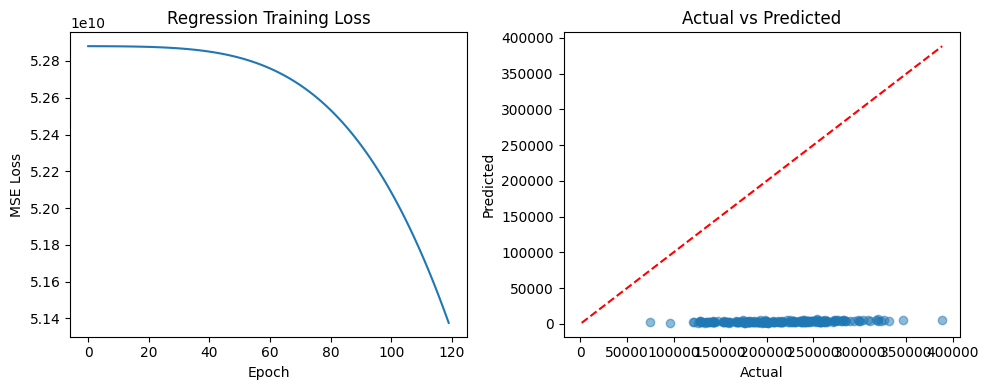

In [4]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses)
plt.title('Regression Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')

plt.subplot(1, 2, 2)
with torch.no_grad():
    preds = reg_model(X_test).squeeze().numpy()
actual = y_test.squeeze().numpy()
plt.scatter(actual, preds, alpha=0.5)
min_v = min(actual.min(), preds.min())
max_v = max(actual.max(), preds.max())
plt.plot([min_v, max_v], [min_v, max_v], 'r--')
plt.title('Actual vs Predicted')
plt.xlabel('Actual')
plt.ylabel('Predicted')

plt.tight_layout()
plt.show()
